In [1]:
import csv
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt

In [2]:
EMBEDDING_DIM = 100
MAXLEN = 16
TRUNCATING = 'post'
PADDING = 'post'
OOV_TOKEN = "<OOV>"
MAX_EXAMPLES = 160000
TRAINING_SPLIT = 0.9

In [3]:
SENTIMENT_CSV = "training_cleaned.csv"

In [4]:
def parse_data_from_file(filename):    
    sentences = []
    labels = []
    with open(filename, 'r') as csvfile:
        reader = csv.reader(csvfile, delimiter=",")     
        for row in reader:
            sentences.append(row[5])
            for_label = row[0]
            if for_label =="0":
                labels.append(0)
            else:
                labels.append(1)
    return sentences, labels

In [5]:
sentences, labels = parse_data_from_file(SENTIMENT_CSV)

In [9]:
print(sentences[5])
print(labels[5])

@Kwesidei not the whole crew 
0


In [10]:
sentences_and_labels = list(zip(sentences, labels))
random.seed(42)
sentences_and_labels = random.sample(sentences_and_labels, MAX_EXAMPLES)
sentences, labels = zip(*sentences_and_labels)

In [11]:
def train_val_split(sentences, labels, training_split):
    train_size = int(len(sentences)*training_split)
    train_sentences = sentences[:train_size]
    train_labels = labels[:train_size]
    validation_sentences = sentences[train_size:]
    validation_labels = labels[train_size:]
    return train_sentences, validation_sentences, train_labels, validation_labels

In [12]:
train_sentences, val_sentences, train_labels, val_labels = train_val_split(sentences, labels, TRAINING_SPLIT)


In [13]:
def fit_tokenizer(train_sentences, oov_token):
    tokenizer = Tokenizer(num_words=len(train_sentences), oov_token="")
    tokenizer.fit_on_texts(train_sentences)
    return tokenizer

In [15]:
tokenizer = fit_tokenizer(train_sentences, OOV_TOKEN)
word_index = tokenizer.word_index
VOCAB_SIZE = len(word_index)
print(VOCAB_SIZE)


128293


In [16]:
def seq_pad_and_trunc(sentences, tokenizer, padding, truncating, maxlen):
    sequences = tokenizer.texts_to_sequences(sentences)
    pad_trunc_sequences = pad_sequences(sequences, maxlen=maxlen, padding=padding, truncating=truncating)
    return pad_trunc_sequences

In [17]:
train_pad_trunc_seq = seq_pad_and_trunc(train_sentences, tokenizer, PADDING, TRUNCATING, MAXLEN)
val_pad_trunc_seq = seq_pad_and_trunc(val_sentences, tokenizer, PADDING, TRUNCATING, MAXLEN)

In [18]:
train_labels = np.array(train_labels)
val_labels = np.array(val_labels)

In [19]:
GLOVE_FILE = 'glove.6B.100d.txt'
GLOVE_EMBEDDINGS = {}
with open(GLOVE_FILE, encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        GLOVE_EMBEDDINGS[word] = coefs

In [22]:
test_word = 'dog'

test_vector = GLOVE_EMBEDDINGS[test_word]

print(f"Representacion {test_word} Vector:\n\n{test_vector}")

Representacion dog Vector:

[ 0.30817    0.30938    0.52803   -0.92543   -0.73671    0.63475
  0.44197    0.10262   -0.09142   -0.56607   -0.5327     0.2013
  0.7704    -0.13983    0.13727    1.1128     0.89301   -0.17869
 -0.0019722  0.57289    0.59479    0.50428   -0.28991   -1.3491
  0.42756    1.2748    -1.1613    -0.41084    0.042804   0.54866
  0.18897    0.3759     0.58035    0.66975    0.81156    0.93864
 -0.51005   -0.070079   0.82819   -0.35346    0.21086   -0.24412
 -0.16554   -0.78358   -0.48482    0.38968   -0.86356   -0.016391
  0.31984   -0.49246   -0.069363   0.018869  -0.098286   1.3126
 -0.12116   -1.2399    -0.091429   0.35294    0.64645    0.089642
  0.70294    1.1244     0.38639    0.52084    0.98787    0.79952
 -0.34625    0.14095    0.80167    0.20987   -0.86007   -0.15308
  0.074523   0.40816    0.019208   0.51587   -0.34428   -0.24525
 -0.77984    0.27425    0.22418    0.20164    0.017431  -0.014697
 -1.0235    -0.39695   -0.0056188  0.30569    0.31748    0.021

In [23]:
print(f"Cada palabra tiene la forma: {test_vector.shape}")

Cada palabra tiene la forma: (100,)


In [24]:
EMBEDDINGS_MATRIX = np.zeros((VOCAB_SIZE+1, EMBEDDING_DIM))
for word, i in word_index.items():
    embedding_vector = GLOVE_EMBEDDINGS.get(word)
    if embedding_vector is not None:
        EMBEDDINGS_MATRIX[i] = embedding_vector

In [27]:
def create_model(vocab_size, embedding_dim, maxlen, embeddings_matrix):
    model = tf.keras.Sequential([ 
        tf.keras.layers.Embedding(vocab_size+1, embedding_dim, input_length=maxlen, weights=[embeddings_matrix], trainable=False), 
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Conv1D(64, 5, activation='relu'),
        tf.keras.layers.MaxPooling1D(pool_size=4),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(loss='binary_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy']) 

    return model

In [28]:
model = create_model(VOCAB_SIZE, EMBEDDING_DIM, MAXLEN, EMBEDDINGS_MATRIX)
history = model.fit(train_pad_trunc_seq, train_labels, epochs=20, validation_data=(val_pad_trunc_seq, val_labels), verbose=1)

Epoch 1/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.6992 - loss: 0.5670 - val_accuracy: 0.7381 - val_loss: 0.5227
Epoch 2/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.7324 - loss: 0.5263 - val_accuracy: 0.7424 - val_loss: 0.5120
Epoch 3/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.7444 - loss: 0.5095 - val_accuracy: 0.7481 - val_loss: 0.5044
Epoch 4/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.7517 - loss: 0.4983 - val_accuracy: 0.7517 - val_loss: 0.5012
Epoch 5/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.7575 - loss: 0.4902 - val_accuracy: 0.7579 - val_loss: 0.4956
Epoch 6/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - accuracy: 0.7631 - loss: 0.4820 - val_accuracy: 0.7601 - val_loss: 0.4924
Epoch 7/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.7666 - loss: 0.4772 - val_accuracy: 0.7581 - val_loss: 0.4956
Epoch 8/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.7679 - loss: 0

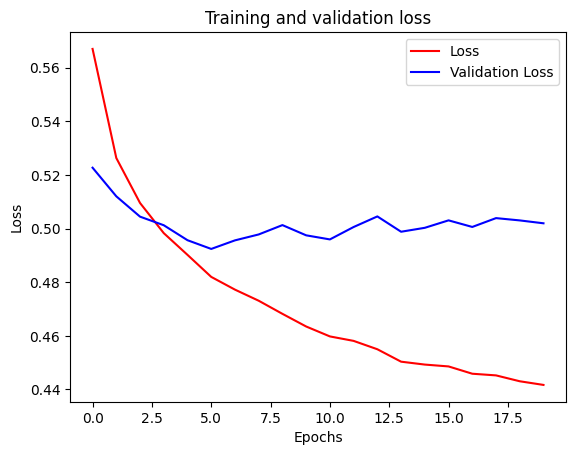

In [29]:
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = [*range(20)]
plt.plot(epochs, loss, 'r')
plt.plot(epochs, val_loss, 'b')
plt.title('Training and validation loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Loss", "Validation Loss"])
plt.show()

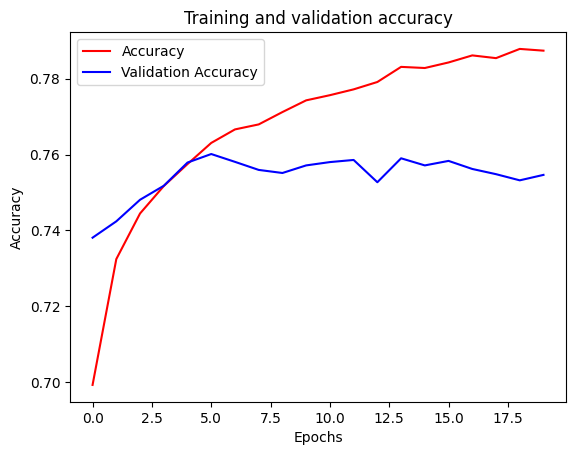

In [30]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
plt.plot(epochs, acc, 'r')
plt.plot(epochs, val_acc, 'b')
plt.title('Training and validation accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Accuracy", "Validation Accuracy"])
plt.show()

In [31]:
def predict_tweet(text, model, tokenizer, maxlen):
    sequence = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(sequence, maxlen=maxlen, padding='post', truncating='post')
    prediction = model.predict(padded, verbose=0)[0][0]
    if prediction >= 0.5:
        sentiment = "POSITIVE 😄"
    else:
        sentiment = "NEGATIVE 😡"
    
    print(f"Tweet: {text}")
    print(f"Score: {prediction:.4f}")
    print(f"Sentimiento: {sentiment}")

In [32]:
predict_tweet("i love this movie so much", model, tokenizer, MAXLEN)
predict_tweet("this is the worst thing ever", model, tokenizer, MAXLEN)
predict_tweet("i dont like this at all", model, tokenizer, MAXLEN)
predict_tweet("this is okay not bad", model, tokenizer, MAXLEN)

Tweet: i love this movie so much
Score: 0.8916
Sentimiento: POSITIVE 😄
Tweet: this is the worst thing ever
Score: 0.0644
Sentimiento: NEGATIVE 😡
Tweet: i dont like this at all
Score: 0.0987
Sentimiento: NEGATIVE 😡
Tweet: this is okay not bad
Score: 0.1376
Sentimiento: NEGATIVE 😡


In [33]:
predict_tweet("it was a great day", model, tokenizer, MAXLEN)

Tweet: it was a great day
Score: 0.9802
Sentimiento: POSITIVE 😄
